In [ ]:
import sys
sys.path.append("..")

import torch

from source.system import SystemParams
from source.policy import NeuralPolicy
from source.utils import read_csv

from source.training import train_net

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.diagnostics import check_energy_balance

from source.stochastic_processes import make_price_function
from source.simulation import rollout_trajectory
from source.plotting import (
    plot_state_trajectories,
    plot_control_trajectories,
    plot_endogenous_trajectories,
    plot_cost_trajectories
)

In [11]:
EPOCHS = 250
BATCH_SIZE = 32

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:24]
future_price = energy_prices[24:]

policy = NeuralPolicy().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

[012] J_train=1.3032 | J_stoch_eval_fixed=1.4530 | J_det_eval=4.8894
[024] J_train=0.8167 | J_stoch_eval_fixed=0.8359 | J_det_eval=4.1389
[036] J_train=0.5400 | J_stoch_eval_fixed=0.4553 | J_det_eval=3.2862
[048] J_train=0.0546 | J_stoch_eval_fixed=0.2176 | J_det_eval=2.4222
[060] J_train=-0.2900 | J_stoch_eval_fixed=0.0663 | J_det_eval=1.6510
[072] J_train=-0.0893 | J_stoch_eval_fixed=-0.0452 | J_det_eval=1.0728
[084] J_train=-0.1769 | J_stoch_eval_fixed=-0.1374 | J_det_eval=0.6612
[096] J_train=-0.2843 | J_stoch_eval_fixed=-0.2090 | J_det_eval=0.3329
[108] J_train=-0.2159 | J_stoch_eval_fixed=-0.2642 | J_det_eval=0.1218
[120] J_train=-0.2242 | J_stoch_eval_fixed=-0.3060 | J_det_eval=-0.0548
[132] J_train=-0.4336 | J_stoch_eval_fixed=-0.3386 | J_det_eval=-0.2160
[144] J_train=-0.6651 | J_stoch_eval_fixed=-0.3651 | J_det_eval=-0.3428
[156] J_train=-0.6997 | J_stoch_eval_fixed=-0.3880 | J_det_eval=-0.4655
[168] J_train=-0.3230 | J_stoch_eval_fixed=-0.4068 | J_det_eval=-0.5793
[180] J_tr

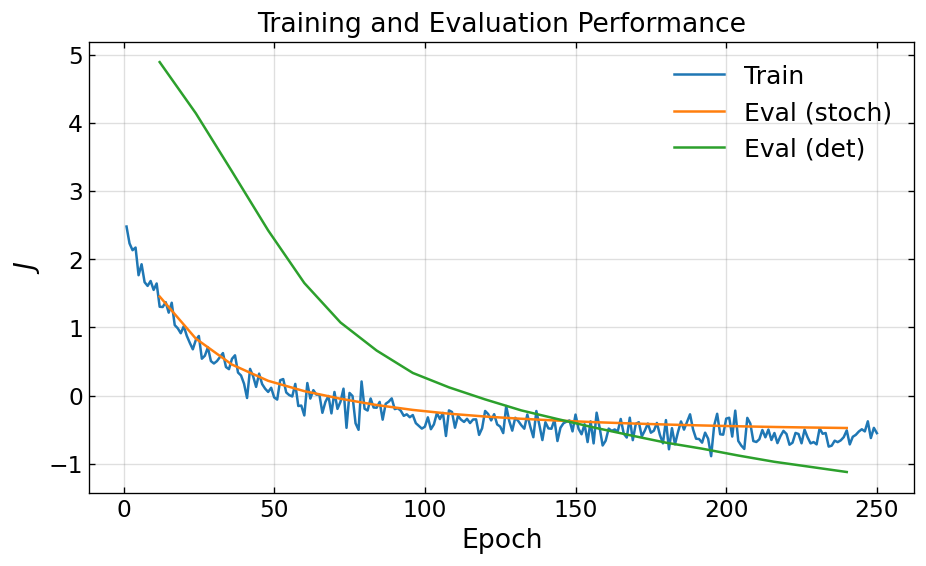

In [14]:
plt.plot(
    res["training_steps"], res["J_train_hist"], label="Train")
plt.plot(res["evaluation_steps"], res["J_stoch_eval_hist"],label="Eval (stoch)")
plt.plot(res["evaluation_steps"], res["J_det_eval_hist"],label="Eval (det)")

plt.xlabel("Epoch")
plt.ylabel(r"$J$")
plt.title("Training and Evaluation Performance")

plt.grid(alpha=0.25)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [15]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(100, 1)

history = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=1,
    device=DEVICE,
)
J_episode = history["J_episode"]
print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: -0.5729


In [16]:
check_energy_balance(history, dt=params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 21.98946189880371,
 'max_Ub': 194.3912811279297}

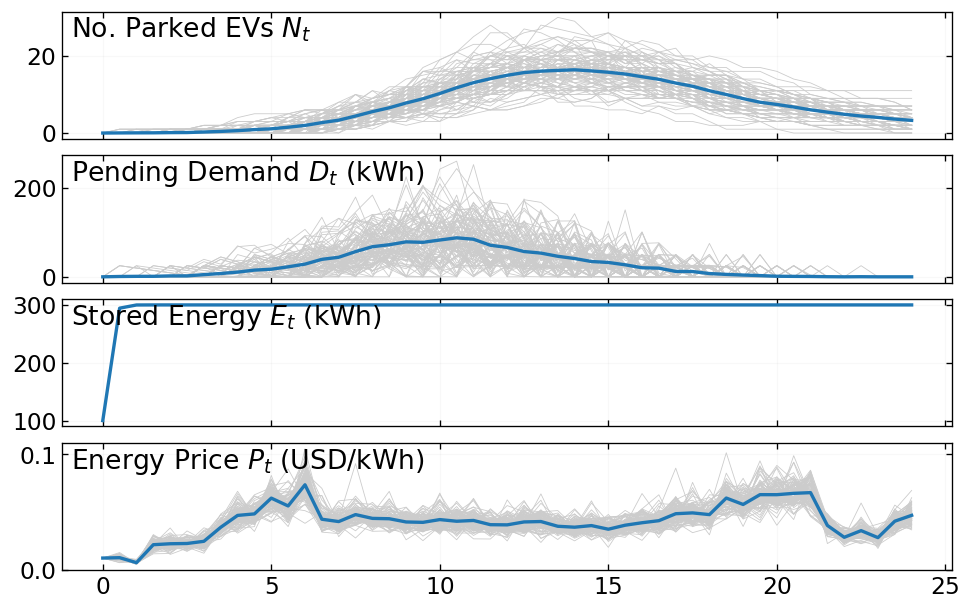

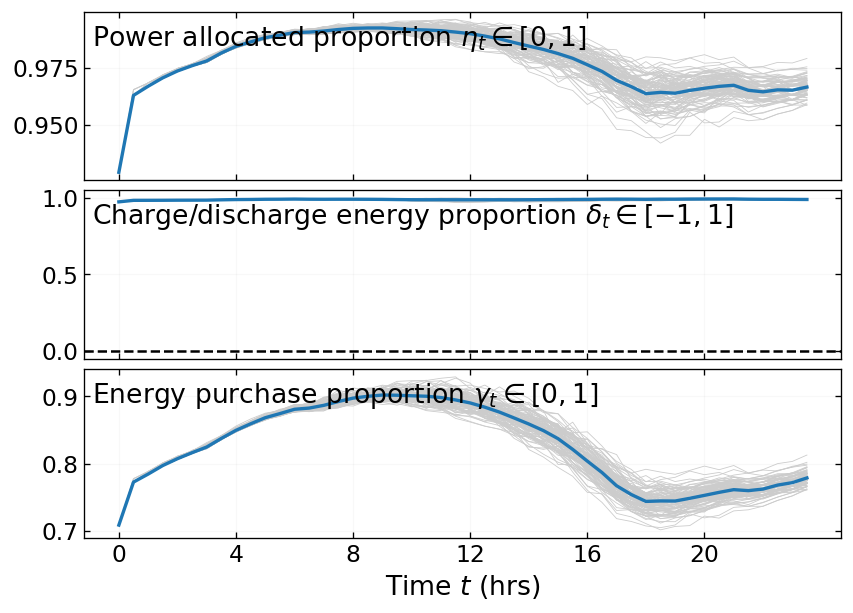

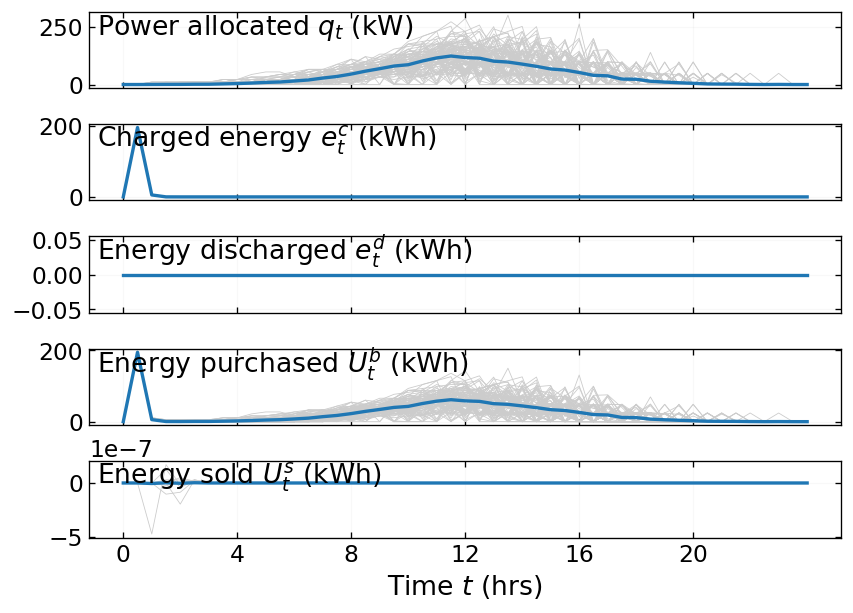

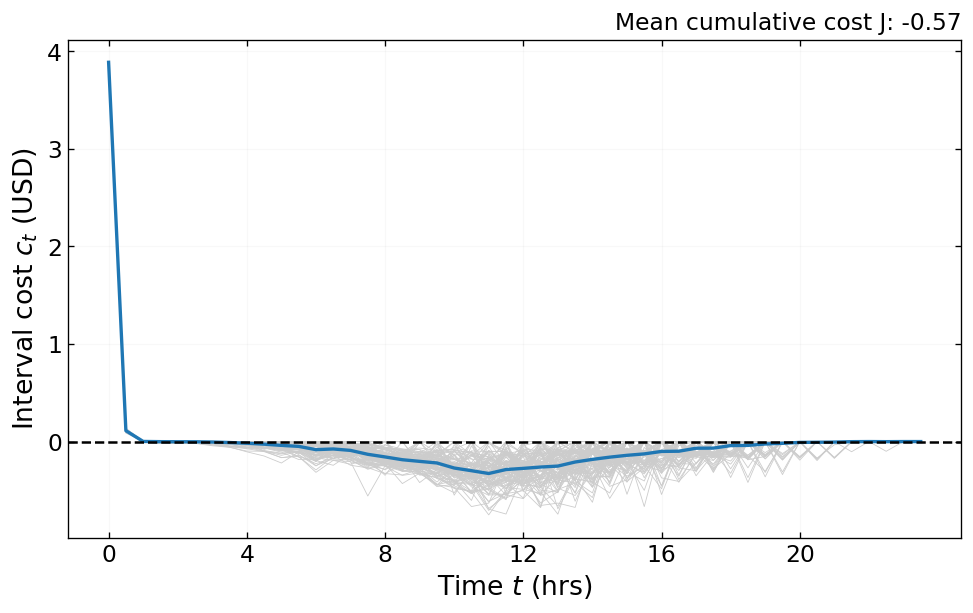

In [17]:
plot_state_trajectories(history)
plot_control_trajectories(history)
plot_endogenous_trajectories(history)
plot_cost_trajectories(history)